<a href="https://colab.research.google.com/github/ankan-git-coder/SUPERVISED-MACHINE-LEARNING/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
true_df = pd.read_csv('True.csv')
false_df = pd.read_csv('Fake.csv')

In [12]:
true_df['label'] = 1
false_df['label'] = 0


In [13]:
data = pd.concat([true_df, false_df])


In [14]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [15]:
false_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [16]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
data['text'] = data['text'].str.lower()
data['title'] = data['title'].str.lower()
data['text'] = data['text'].apply(nltk.word_tokenize)
data['title'] = data['title'].apply(nltk.word_tokenize)

# Remove stopwords
stop_words = set(stopwords.words('english'))
data['text'] = data['text'].apply(lambda x: [word for word in x if word not in stop_words])
data['title'] = data['title'].apply(lambda x: [word for word in x if word not in stop_words])


In [18]:
tfidf_Vectorizer = TfidfVectorizer(max_features=5000)
text_tfidf = tfidf_Vectorizer.fit_transform(data['text'].apply(lambda x: ' '.join(x)))
title_tfidf = tfidf_Vectorizer.transform(data['title'].apply(lambda x: ' '.join(x)))


In [19]:
X = text_tfidf
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the shapes of training and testing data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



X_train shape: (35918, 5000)
X_test shape: (8980, 5000)
y_train shape: (35918,)
y_test shape: (8980,)


Accuracy: 0.94


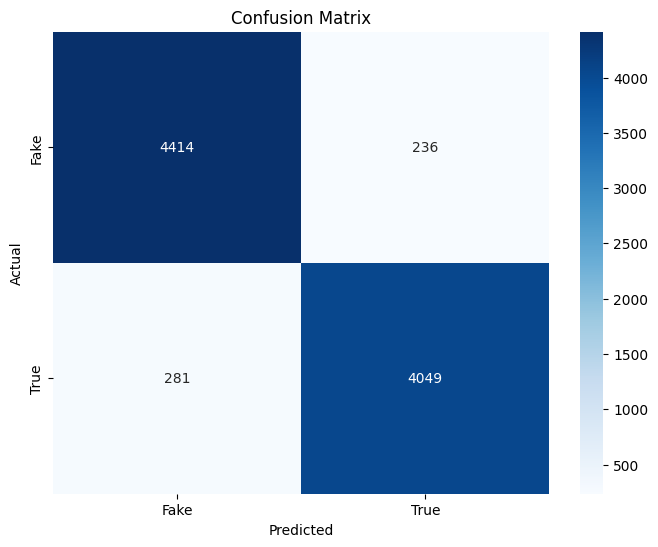

In [20]:
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)
y_pred = naive_bayes_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()





In [21]:
# DECISION TREEE
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train,y_train)

def evaluate_decision_tree(model,X_test,y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)


    return accuracy,confusion

dt_accuracy, dt_confusion = evaluate_decision_tree(decision_tree, X_test, y_test)
print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Confusion Matrix:\n", dt_confusion)



Decision Tree Accuracy: 0.9968819599109131
Decision Tree Confusion Matrix:
 [[4639   11]
 [  17 4313]]


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Define and train the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

# Evaluate the Random Forest model
def evaluate_random_forest(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    return accuracy, confusion

# Evaluate Random Forest
rf_accuracy, rf_confusion = evaluate_random_forest(random_forest, X_test, y_test)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Confusion Matrix:\n", rf_confusion)

Random Forest Accuracy: 0.9983296213808464
Random Forest Confusion Matrix:
 [[4643    7]
 [   8 4322]]


In [23]:
from sklearn.svm import SVC
support_vector = SVC(kernel= 'linear')
support_vector.fit(X_train,y_train)
def evaluate_svm(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)
    return accuracy, confusion

# Evaluate Random Forest
svm_accuracy, svm_confusion = evaluate_svm(support_vector, X_test, y_test)
print("svm Accuracy:", svm_accuracy)
print("svm Confusion Matrix:\n", svm_confusion)


svm Accuracy: 0.99543429844098
svm Confusion Matrix:
 [[4621   29]
 [  12 4318]]


In [26]:
from sklearn.linear_model import LogisticRegression

# Define and train the Logistic Regression model
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

# Evaluate the Logistic Regression model
def evaluate_logistic_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    return accuracy, confusion

# Evaluate Logistic Regression
lr_accuracy, lr_confusion = evaluate_logistic_regression(logistic_regression, X_test, y_test)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Confusion Matrix:\n", lr_confusion)

Logistic Regression Accuracy: 0.9918708240534521
Logistic Regression Confusion Matrix:
 [[4601   49]
 [  24 4306]]


In [27]:

from sklearn.metrics import precision_score, recall_score, f1_score

# Testing and evaluating Logistic Regression
lr_test_predictions = logistic_regression.predict(X_test)
lr_test_precision = precision_score(y_test, lr_test_predictions)
lr_test_recall = recall_score(y_test, lr_test_predictions)
lr_test_f1 = f1_score(y_test, lr_test_predictions)

# Print precision, recall, and F1 score for Logistic Regression
print("Logistic Regression Test Precision:", lr_test_precision)
print("Logistic Regression Test Recall:", lr_test_recall)
print("Logistic Regression Test F1 Score:", lr_test_f1)





Logistic Regression Test Precision: 0.9887485648679678
Logistic Regression Test Recall: 0.9944572748267898
Logistic Regression Test F1 Score: 0.991594703511802


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Testing the Random Forest model on the test data
rf_test_predictions = random_forest.predict(X_test)

# Evaluate Random Forest on the test data
rf_test_precision = precision_score(y_test, rf_test_predictions)
rf_test_recall = recall_score(y_test, rf_test_predictions)
rf_test_f1 = f1_score(y_test, rf_test_predictions)

# Print precision, recall, and F1 score for Random Forest
print("Random Forest Test Precision:", rf_test_precision)
print("Random Forest Test Recall:", rf_test_recall)
print("Random Forest Test F1 Score:", rf_test_f1)


Random Forest Test Precision: 0.9983829983829984
Random Forest Test Recall: 0.9981524249422633
Random Forest Test F1 Score: 0.9982676983485391


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Testing the Decision Tree model on the test data
dt_test_predictions = decision_tree.predict(X_test)

# Evaluate Decision Tree on the test data
dt_test_precision = precision_score(y_test, dt_test_predictions)
dt_test_recall = recall_score(y_test, dt_test_predictions)
dt_test_f1 = f1_score(y_test, dt_test_predictions)

# Print precision, recall, and F1 score for Decision Tree
print("Decision Tree Test Precision:", dt_test_precision)
print("Decision Tree Test Recall:", dt_test_recall)
print("Decision Tree Test F1 Score:", dt_test_f1)


Decision Tree Test Precision: 0.9974560592044404
Decision Tree Test Recall: 0.9960739030023095
Decision Tree Test F1 Score: 0.9967645019644095


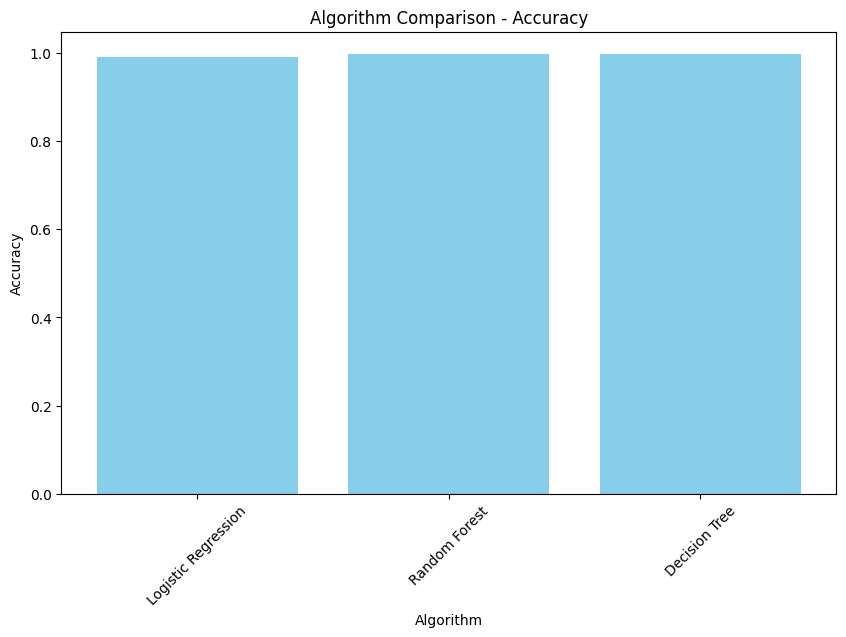

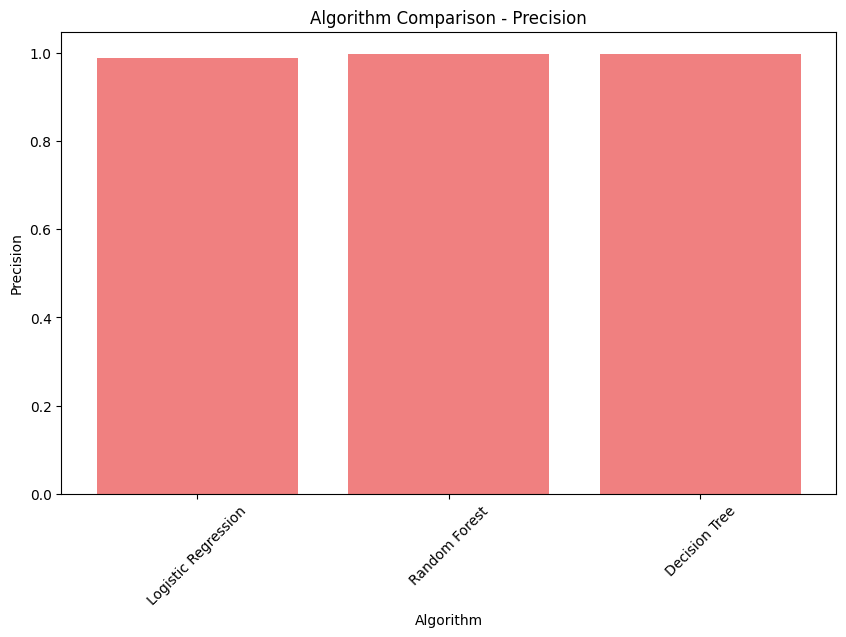

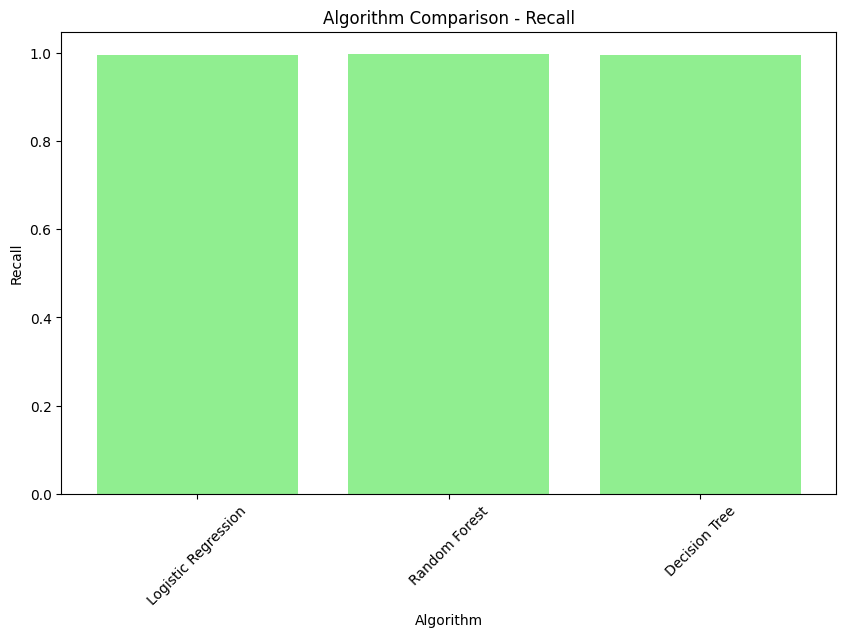

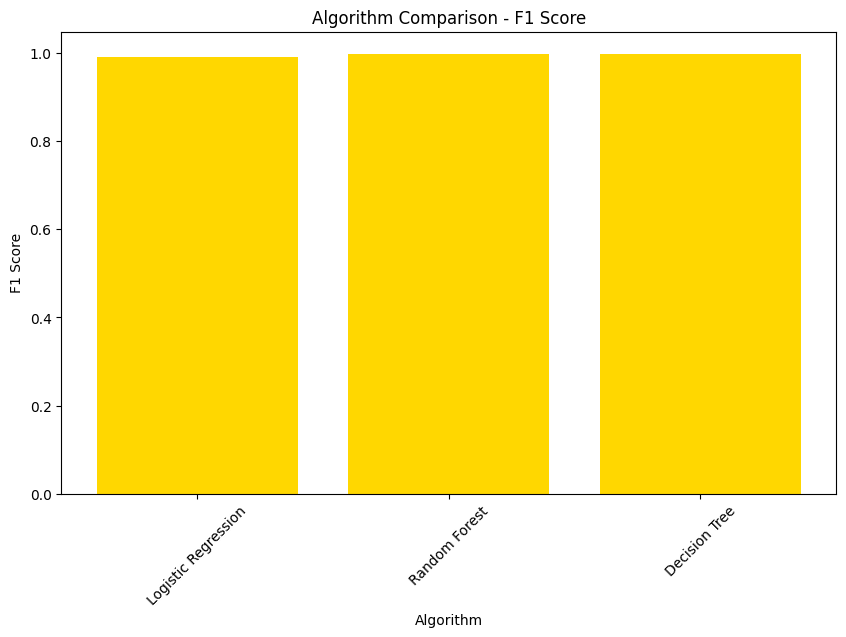

In [30]:
import matplotlib.pyplot as plt

# Define the algorithm names and their corresponding metrics
algorithms = ['Logistic Regression', 'Random Forest',  'Decision Tree']
accuracies = [lr_accuracy, rf_accuracy,  dt_accuracy]
precisions = [lr_test_precision, rf_test_precision,  dt_test_precision]
recalls = [lr_test_recall, rf_test_recall, dt_test_recall]
f1_scores = [lr_test_f1, rf_test_f1, dt_test_f1]

# Create a bar chart for accuracy
plt.figure(figsize=(10, 6))
plt.bar(algorithms, accuracies, color='skyblue')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Algorithm Comparison - Accuracy')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for precision
plt.figure(figsize=(10, 6))
plt.bar(algorithms, precisions, color='lightcoral')
plt.xlabel('Algorithm')
plt.ylabel('Precision')
plt.title('Algorithm Comparison - Precision')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for recall
plt.figure(figsize=(10, 6))
plt.bar(algorithms, recalls, color='lightgreen')
plt.xlabel('Algorithm')
plt.ylabel('Recall')
plt.title('Algorithm Comparison - Recall')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for F1 score
plt.figure(figsize=(10, 6))
plt.bar(algorithms, f1_scores, color='gold')
plt.xlabel('Algorithm')
plt.ylabel('F1 Score')
plt.title('Algorithm Comparison - F1 Score')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x800 with 0 Axes>

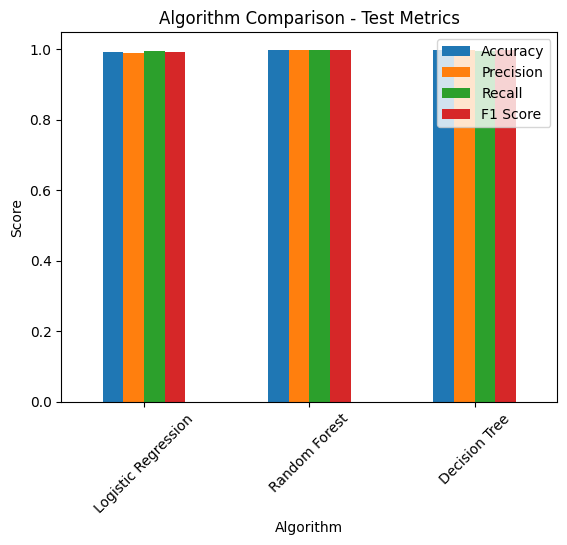

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the algorithm names and their corresponding metrics
algorithms = ['Logistic Regression', 'Random Forest', 'Decision Tree']
accuracy_scores = [lr_accuracy, rf_accuracy,  dt_accuracy]
precision_scores = [lr_test_precision, rf_test_precision,  dt_test_precision]
recall_scores = [lr_test_recall, rf_test_recall,  dt_test_recall]
f1_scores = [lr_test_f1, rf_test_f1,  dt_test_f1]

# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'Algorithm': algorithms,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

# Set the algorithm column as the index for plotting
results_df.set_index('Algorithm', inplace=True)
plt.figure(figsize=(12, 8))
results_df.plot(kind='bar', stacked=False)
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.title('Algorithm Comparison - Test Metrics')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()


In [34]:
import nltk
from nltk.corpus import stopwords

# Define a function for predicting titles
def predict_title(title_text):
    # Preprocess the title
    preprocessed_title_text = title_text.lower()
    preprocessed_title_text = nltk.word_tokenize(preprocessed_title_text)
    preprocessed_title_text = [word for word in preprocessed_title_text if word not in stop_words]

    # Convert the preprocessed text into TF-IDF vectors
    tfidf_vector = tfidf_Vectorizer.transform([" ".join(preprocessed_title_text)])

    # Make the prediction
    prediction = naive_bayes_model.predict(tfidf_vector)

    return prediction

# Example titles
title_text_1 = "Donald Trump Sends Out Embarrassing New Year"
title_text_2 = "As U.S. budget fight looms, Republicans flip their fiscal script"

# Predict and display results for both titles
prediction_1 = predict_title(title_text_1)
prediction_2 = predict_title(title_text_2)

if prediction_1 == 1:
    print("Title 1: The news is likely true.")
else:
  print("Title 1: The news is likely fake.")

if prediction_2 == 1:
    print("Title 2: The news is likely true.")
else:
    print("Title 2: The news is likely fake.")




Title 1: The news is likely fake.
Title 2: The news is likely true.
